In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

train_dir = '/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_dir = '/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'
test_dir = '/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/test'

batch_size = 32
img_size = (224, 224) #MobileNetV2

#Pipeline

# Training generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation generator
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False #confusion matrix later
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print(f"Detected {num_classes} classes.")

2026-04-28 21:03:28.395169: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777410208.584506      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777410208.639611      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777410209.061656      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777410209.061694      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777410209.061696      24 computation_placer.cc:177] computation placer alr

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Detected 38 classes.


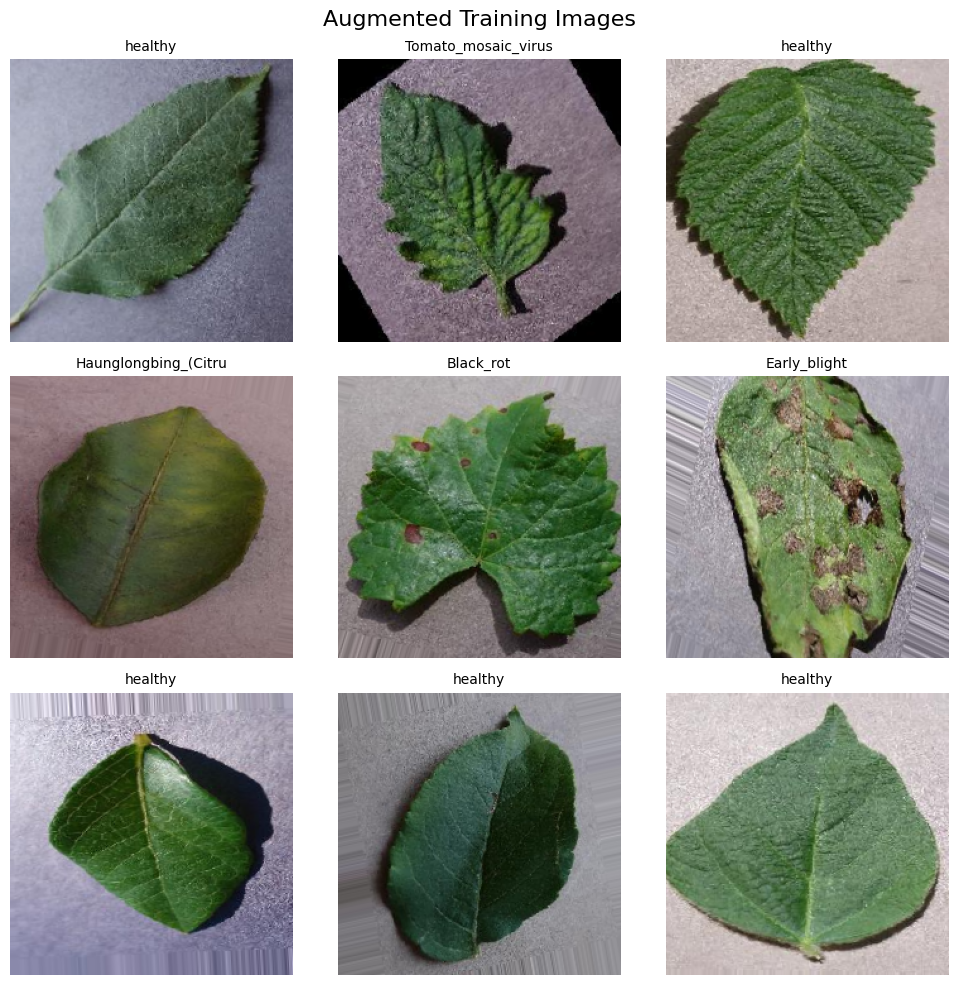

In [2]:
# Visualize AUG
images, labels = next(train_generator)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    label_idx = np.argmax(labels[i])
    short_name = class_names[label_idx].split('___')[-1][:20] 
    plt.title(short_name, fontsize=10)
    plt.axis("off")
plt.suptitle("Augmented Training Images", fontsize=16)
plt.tight_layout()
plt.show()

# Phase 1 - Custom CNN

Building Custom CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777410253.206532      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777410253.212372      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,835,622 (37.52 MB)

...

   2/2197 ━━━━━━━━━━━━━━━━━━━━ 2:58 81ms/step - accuracy: 0.0312 - loss: 4.7093  

I0000 00:00:1777410266.948939      89 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 502/2197 ━━━━━━━━━━━━━━━━━━━━ 13:17 471ms/step - accuracy: 0.0903 - loss: 3.4600

2026-04-28 21:08:25.726725: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 21:08:25.873094: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1187s 535ms/step - accuracy: 0.3041 - loss: 2.5116 - val_accuracy: 0.7407 - val_loss: 0.8317
Epoch 2/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 836s 381ms/step - accuracy: 0.7040 - loss: 0.9489 - val_accuracy: 0.8340 - val_loss: 0.5241
Epoch 3/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 829s 377ms/step - accuracy: 0.7828 - loss: 0.6926 - val_accuracy: 0.8720 - val_loss: 0.3968


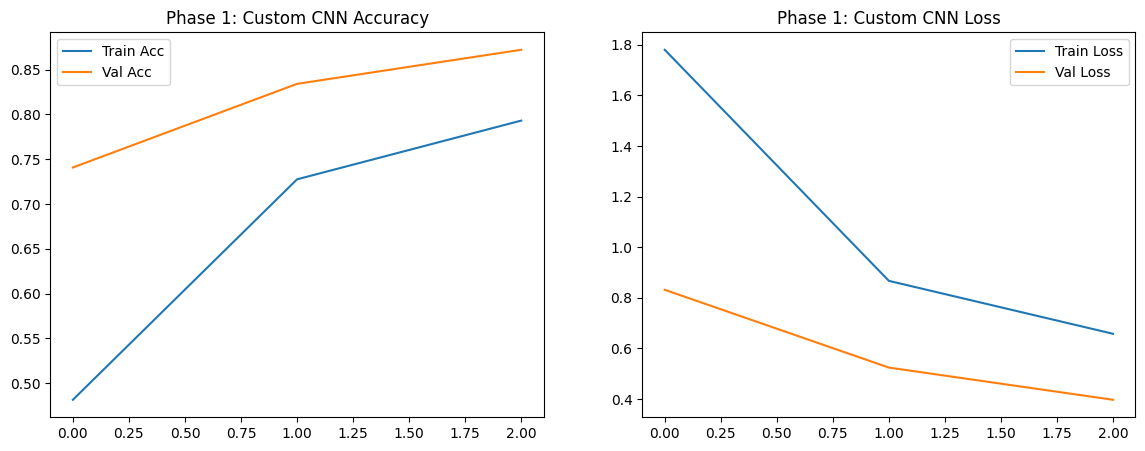

In [3]:
# 1=> Build CNN
print("Building Custom CNN...")
custom_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.3),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

custom_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
custom_cnn.summary()

# 2=> Train CNN
print("\nTraining Phase 1 Model (Custom CNN)...")
history_custom = custom_cnn.fit(
    train_generator,
    epochs=3, # Adjust epochs based on your available time
    validation_data=valid_generator
)

# 3=> PLot ACC & Loss
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history_custom.history['accuracy'], label='Train Acc')
ax[0].plot(history_custom.history['val_accuracy'], label='Val Acc')
ax[0].set_title('Phase 1: Custom CNN Accuracy')
ax[0].legend()

ax[1].plot(history_custom.history['loss'], label='Train Loss')
ax[1].plot(history_custom.history['val_loss'], label='Val Loss')
ax[1].set_title('Phase 1: Custom CNN Loss')
ax[1].legend()
plt.show()

# Phase 2 : Transfer Learning

In [4]:
# 1- Load Pre-Trained Base-Model
print("Loading MobileNetV2 Base...")
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base layers
base_model.trainable = False

# 2- Build Head
tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

tl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

# 3-Train Head
print("\nTraining Phase 2 Model Head...")
history_tl_head = tl_model.fit(
    train_generator,
    epochs=3,
    validation_data=valid_generator
)

# 4- Fine Tunning
print("\nUnfreezing Base for Fine-Tuning...")
base_model.trainable = True

# Compile with a very low learning rate
tl_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
                 loss='categorical_crossentropy', 
                 metrics=['accuracy'])

history_tl_fine = tl_model.fit(
    train_generator,
    epochs=2,
    validation_data=valid_generator
)

Loading MobileNetV2 Base...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

...

2073/2197 ━━━━━━━━━━━━━━━━━━━━ 43s 350ms/step - accuracy: 0.7492 - loss: 0.9199

2026-04-28 22:04:21.888965: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 22:04:22.024951: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.7549 - loss: 0.8971

2026-04-28 22:05:58.906335: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 22:05:59.041552: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 850s 379ms/step - accuracy: 0.7550 - loss: 0.8969 - val_accuracy: 0.9195 - val_loss: 0.2538
Epoch 2/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 847s 385ms/step - accuracy: 0.9149 - loss: 0.2669 - val_accuracy: 0.9236 - val_loss: 0.2338
Epoch 3/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 812s 369ms/step - accuracy: 0.9241 - loss: 0.2341 - val_accuracy: 0.9342 - val_loss: 0.1942

Unfreezing Base for Fine-Tuning...
Epoch 1/2
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 884s 381ms/step - accuracy: 0.7366 - loss: 1.2069 - val_accuracy: 0.8954 - val_loss: 0.3296
Epoch 2/2
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 808s 368ms/step - accuracy: 0.9385 - loss: 0.1842 - val_accuracy: 0.9521 - val_loss: 0.1379


# Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


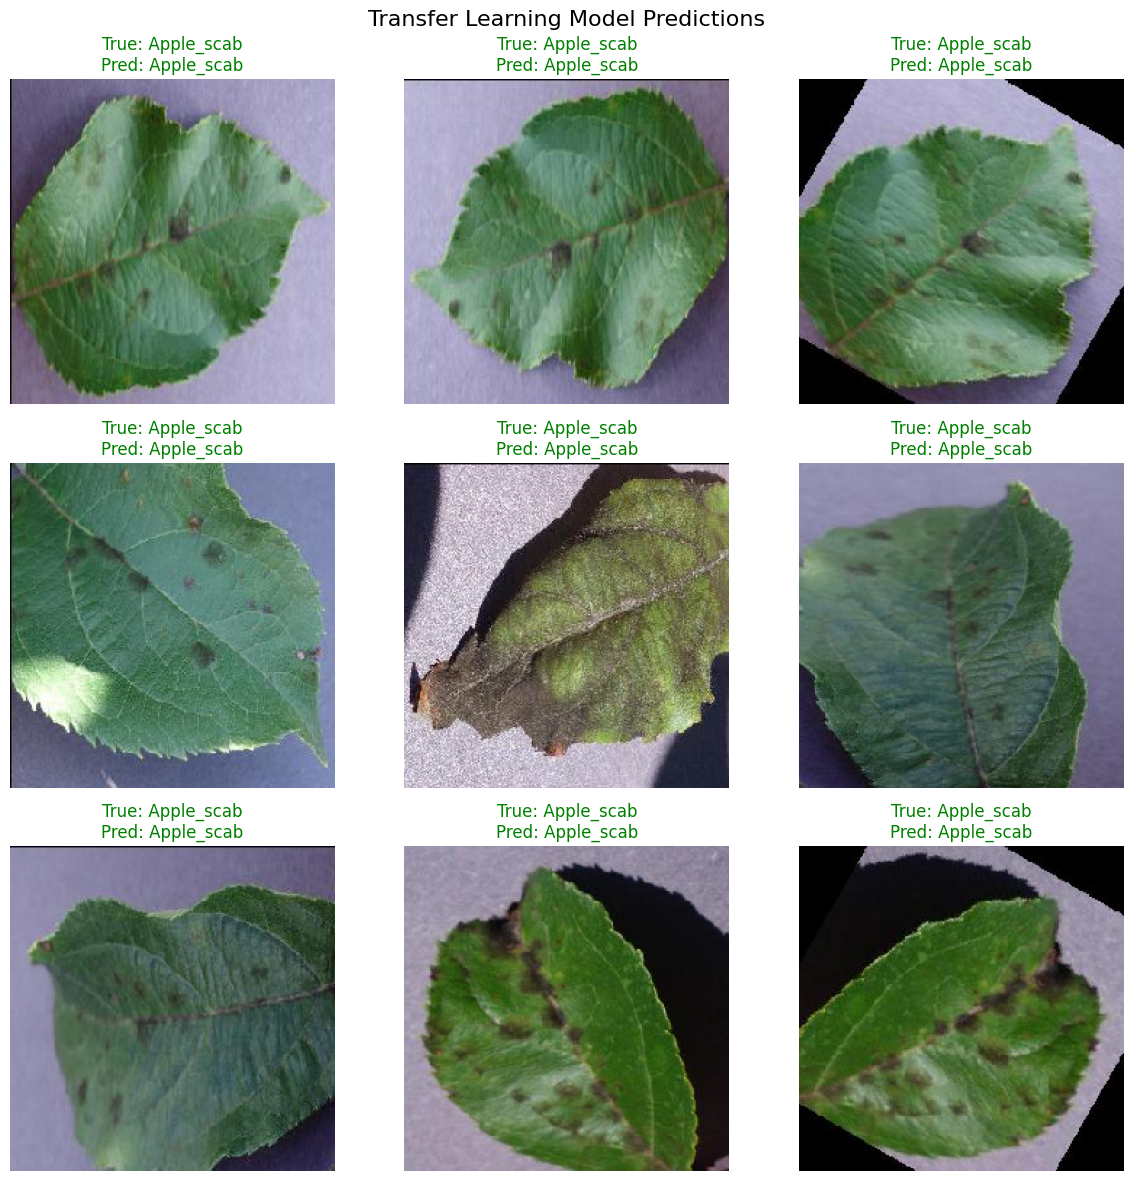

Generating Confusion Matrix...
550/550 ━━━━━━━━━━━━━━━━━━━━ 38s 62ms/step


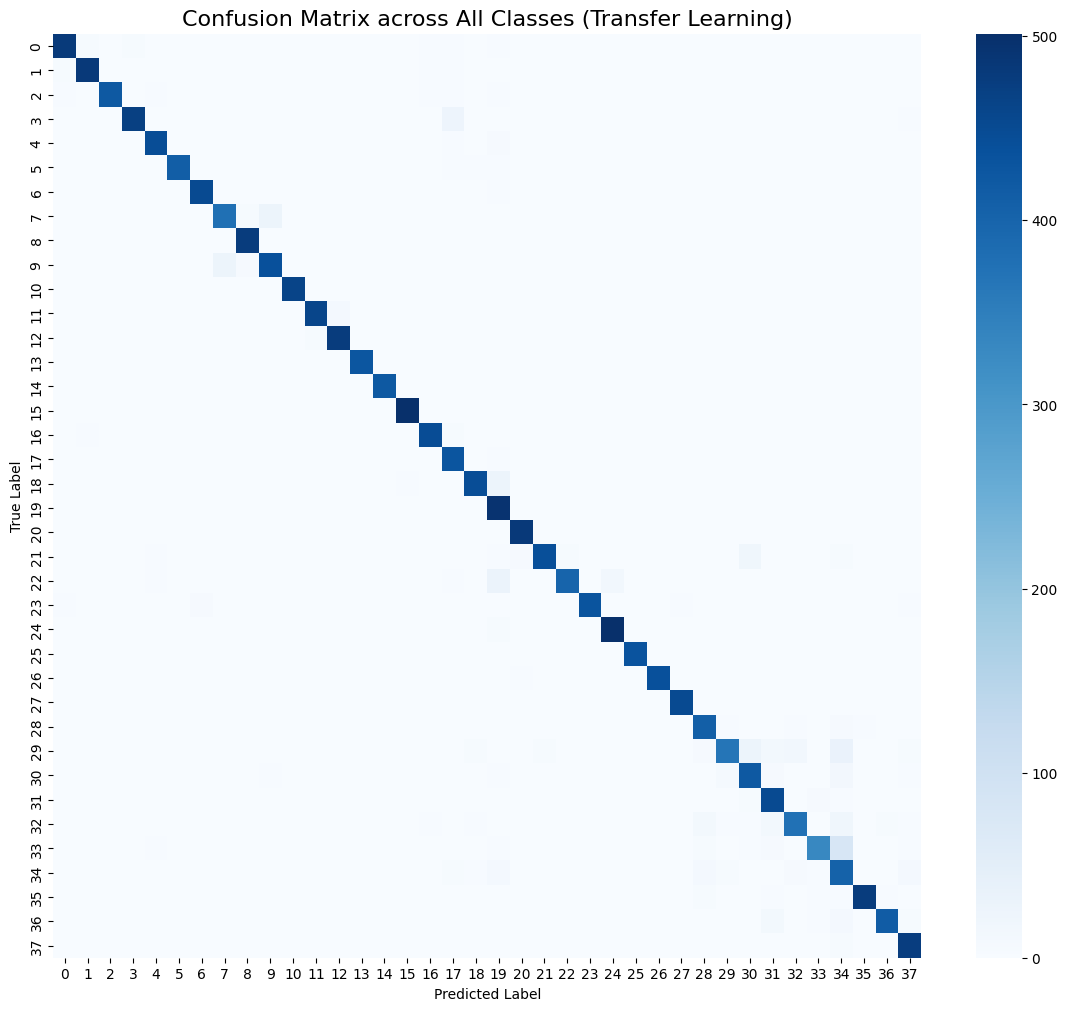

In [5]:
# 1- Plot Predctionts ==> 9 samples
test_images, test_labels = next(valid_generator)
predictions = tl_model.predict(test_images)

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[i])
    
    true_idx = np.argmax(test_labels[i])
    pred_idx = np.argmax(predictions[i])
    color = 'green' if true_idx == pred_idx else 'red'
    
    true_name = class_names[true_idx].split('___')[-1][:15]
    pred_name = class_names[pred_idx].split('___')[-1][:15]
    
    plt.title(f"True: {true_name}\nPred: {pred_name}", color=color)
    plt.axis("off")
plt.suptitle("Transfer Learning Model Predictions", fontsize=16)
plt.tight_layout()
plt.show()

# 2- Confusion Matrix
print("Generating Confusion Matrix...")
valid_generator.reset()
all_preds = tl_model.predict(valid_generator)
all_pred_classes = np.argmax(all_preds, axis=1)
true_classes = valid_generator.classes

cm = confusion_matrix(true_classes, all_pred_classes)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues') 
plt.title('Confusion Matrix across All Classes (Transfer Learning)', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Analysis

## Task Analysis

**1. Compare Phase 1 vs Phase 2 accuracy:**
Phase 2 (Transfer Learning with MobileNetV2) achieves significantly higher accuracy in fewer epochs compared to Phase 1 (Custom CNN). The Custom CNN struggles to learn complex feature representations from scratch given the limited training time, whereas MobileNetV2 leverages state-of-the-art pretrained weights (from ImageNet) to quickly converge and accurately classify the plant diseases.

**2. How many parameters does each model have?**
* **Phase 1 (Custom CNN):** Based on the model summary, this architecture has roughly 37.23 million parameters, heavily concentrated in the transition from the final Conv2D layer to the Dense classification head.
* **Phase 2 (MobileNetV2):** Contains approximately 2.2 million parameters. Despite having vastly fewer parameters, its advanced architecture (inverted residuals and linear bottlenecks) makes it far more efficient and accurate.

**3. What does dropout prevent?**
Dropout prevents **overfitting**. During training, it randomly deactivates a percentage of neurons in the layer. This prevents the network from relying too heavily on any single node or path, forcing the model to learn more robust, generalized features rather than memorizing the specific training data.